# NB15 — Solar Weight Calibration: Heating Training Data + Cross-Dataset Comparison

## Goal
Repeat the NB14 solar weight calibration analysis using `heating_training_data.csv.gz`
(outdoor temp < 18°C), then compare with the NB14 cooling-data results.

## Key differences from NB14
- Data: `heating_training_data.csv.gz` (85k rows, AT < 18°C)
- Column: `thermal_power_w` (Watts) instead of `thermal_power_kw` (kW)
- Has `is_hp_active` flag for clean HP-on/HP-off segmentation
- More heating-mode data available, less cooling/passive data

## Phases
- **A**: Data loading, Open Meteo solar fetch, sun positions, blind segmentation
- **B**: HP-only equilibrium residuals
- **C**: Solar weight calibration (heating mode + cooling/passive mode)
- **D**: Sun-angle analysis (elevation, azimuth, correction methods)
- **E**: Cross-dataset comparison (NB14 cooling results vs NB15 heating results)
- **F**: Implementation plan for main workflow

In [1]:
# === PHASE A — Cell 1: Imports, data loading ===
import sys, warnings, calendar, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize
from pathlib import Path
from datetime import datetime, timedelta
import pytz
import requests, urllib3
from astral import Observer
from astral.sun import elevation as sun_elevation, azimuth as sun_azimuth

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DATA_PATH = PROJECT_ROOT / "Logs_and_models" / "heating_training_data.csv.gz"
LAT, LON = 48.928, 10.069
TZ = pytz.timezone("Europe/Berlin")
OBSERVER = Observer(latitude=LAT, longitude=LON)

# --- Locked heating parameters from unified_thermal_state (heat_pump channel) ---
HLC_LOCKED  = 0.1194  # heat_loss_coefficient [kW/K]
OE_LOCKED   = 0.8377  # outlet_effectiveness [kW/K]
TAU_LOCKED  = 4.83    # thermal_time_constant [h]
DT_FLOOR    = 2.64    # delta_t_floor [K]
DT_H        = 5.0 / 60.0  # 5-minute intervals

BLIND_THRESHOLD = 23.0
MIN_PV_POWER = 100  # W
MIN_THERMAL_POWER_W = 500  # W (= 0.5 kW)

PV_COL = "PV_Generate"

# --- Load heating training data ---
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw dataset: {len(df_raw)} rows, {len(df_raw.columns)} columns")
print(f"Columns: {list(df_raw.columns)}")

# Reconstruct hour and doy from sin/cos features
df_raw["hour"] = (np.degrees(np.arctan2(df_raw["hour_sin"], df_raw["hour_cos"])) / 15) % 24

# Clean outliers
mask_clean = (
    (df_raw["AT"] > -15) & (df_raw["AT"] < 20) &
    (df_raw["VLT"] > 10) & (df_raw["VLT"] < 45) &
    (df_raw[PV_COL] < 20000)  # Remove PV outliers (max realistic ~15kW)
)
df = df_raw[mask_clean].copy().reset_index(drop=True)

# Reconstruct approximate timestamps
doy_angle = np.arctan2(df["doy_sin"], df["doy_cos"])
doy_vals = (doy_angle * 365.25 / (2 * np.pi)) % 365.25
df["doy_approx"] = doy_vals.round().astype(int).clip(1, 365)
df["hour_approx"] = df["hour"].round().astype(int).clip(0, 23)

# Convert thermal_power_w to kW for consistency with NB14
df["thermal_power_kw"] = df["thermal_power_w"] / 1000.0

print(f"\nCleaned dataset: {len(df)} rows (removed {len(df_raw) - len(df)} outliers)")
print(f"AT range: {df['AT'].min():.1f} – {df['AT'].max():.1f}°C")
print(f"Indoor temp range: {df['indoor_temp'].min():.1f} – {df['indoor_temp'].max():.1f}°C")
print(f"PV range: {df[PV_COL].min():.0f} – {df[PV_COL].max():.0f} W")
print(f"Thermal power range: {df['thermal_power_kw'].min():.2f} – {df['thermal_power_kw'].max():.2f} kW")
print(f"is_hp_active: {df['is_hp_active'].value_counts().to_dict()}")
print(f"DOY range: {df['doy_approx'].min()} – {df['doy_approx'].max()}")

# --- Split into heating and cooling/passive modes ---
df_heat = df[(df["thermal_power_w"] > MIN_THERMAL_POWER_W) | (df["is_hp_active"] == 1)].copy().reset_index(drop=True)
df_cool = df[(df["thermal_power_w"] <= 100) & (df["is_hp_active"] == 0)].copy().reset_index(drop=True)

print(f"\n=== Mode Split ===")
print(f"Heating (tp_w > {MIN_THERMAL_POWER_W}W or HP active): {len(df_heat)} rows")
print(f"Cooling/passive (tp_w <= 100W and HP off):    {len(df_cool)} rows")
print(f"Other (transition):                          {len(df) - len(df_heat) - len(df_cool)} rows")

Raw dataset: 85078 rows, 52 columns
Columns: ['indoor_temp', 'indoor_margin', 'indoor_trend_30m', 'indoor_trend_1h', 'AT', 'at_delta_indoor', 'AT_roh_1h', 'AT_roh_2h', 'AT_roh_3h', 'AT_roh_4h', 'VLT', 'RLT', 'delta_t', 'outlet_indoor_diff', 'thermal_power_w', 'fireplace_on', 'tv_on', 'fireplace_lag_1h', 'fireplace_lag_2h', 'fireplace_lag_3h', 'fireplace_lag_4h', 'tv_lag_30m', 'tv_lag_1h', 'PV_Generate', 'pv_roll_1h', 'pv_roll_2h', 'pv_forecast_1h', 'pv_forecast_2h', 'pv_forecast_3h', 'pv_forecast_4h', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wind_speed', 'indoor_temp_gradient', 'living_room_temp', 'is_hp_active', 'is_weekend', 'thermal_power_rolling_1h', 'indoor_margin_rate', 'is_overshoot', 'd_inlet_temp_60min', 'is_equilibrium', 'heat_loss_driving_force', 'delta_T_indoor_lag1', 'Q_wp', 'solar_thermal_proxy', 'pv_forecast_delta', 'shading_proxy', 'heat_loss_interaction', 'label']

Cleaned dataset: 85071 rows (removed 7 outliers)
AT range: -12.1 – 18.0°C
Indoor temp range: 20.5 –

In [2]:
# === PHASE A — Cell 2: Fetch Open Meteo GHI / DNI / DHI ===
chunks = []
print("Fetching Open Meteo solar + cloud data (monthly chunks)...")
y, m = 2025, 5
while (y, m) <= (2026, 5):
    last_day = calendar.monthrange(y, m)[1]
    s_str = f"{y}-{m:02d}-01"
    e_str = f"{y}-{m:02d}-{last_day:02d}"
    try:
        url = (
            f"https://archive-api.open-meteo.com/v1/archive?"
            f"latitude={LAT}&longitude={LON}&start_date={s_str}&end_date={e_str}"
            f"&hourly=shortwave_radiation,cloud_cover,direct_normal_irradiance,diffuse_radiation"
            f"&timezone=Europe%2FBerlin"
        )
        resp = requests.get(url, timeout=60, verify=False)
        resp.raise_for_status()
        data = resp.json()
        h = data["hourly"]
        chunk_df = pd.DataFrame({
            "timestamp": pd.to_datetime(h["time"]),
            "ghi_wm2": h["shortwave_radiation"],
            "cloud_cover": h["cloud_cover"],
            "dni_wm2": h["direct_normal_irradiance"],
            "dhi_wm2": h["diffuse_radiation"],
        })
        chunks.append(chunk_df)
        print(f"  {s_str}: {len(chunk_df)} rows OK")
    except Exception as e:
        print(f"  {s_str}: FAILED ({str(e)[:80]})")
    m += 1
    if m > 12:
        m, y = 1, y + 1

solar_df = pd.concat(chunks, ignore_index=True).set_index("timestamp").sort_index()
solar_df = solar_df[~solar_df.index.duplicated(keep="first")]
print(f"\nOpen Meteo data: {len(solar_df)} rows, {solar_df.index[0]} → {solar_df.index[-1]}")
print(f"GHI range: {solar_df['ghi_wm2'].min()} – {solar_df['ghi_wm2'].max()} W/m²")

Fetching Open Meteo solar + cloud data (monthly chunks)...
  2025-05-01: 744 rows OK
  2025-06-01: 720 rows OK
  2025-07-01: 744 rows OK
  2025-08-01: 744 rows OK
  2025-09-01: 720 rows OK
  2025-10-01: 744 rows OK
  2025-11-01: 720 rows OK
  2025-12-01: 744 rows OK
  2026-01-01: 744 rows OK
  2026-02-01: 672 rows OK
  2026-03-01: 744 rows OK
  2026-04-01: 720 rows OK
  2026-05-01: 744 rows OK

Open Meteo data: 9504 rows, 2025-05-01 00:00:00 → 2026-05-31 23:00:00
GHI range: 0.0 – 918.0 W/m²


Computing sun positions via astral...
Merged heating data: 45548 rows
Merged cooling/passive data: 34321 rows

=== Blind Segmentation (threshold = 23.0°C) ===
--- HEATING MODE ---
  PV active, blind OPEN:    10563 rows (23.2%)
  PV active, blind CLOSED:   2375 rows (5.2%)
  Night / low PV:           32610 rows (71.6%)
--- COOLING/PASSIVE MODE ---
  PV active, blind OPEN:    12098 rows (35.2%)
  PV active, blind CLOSED:   6151 rows (17.9%)


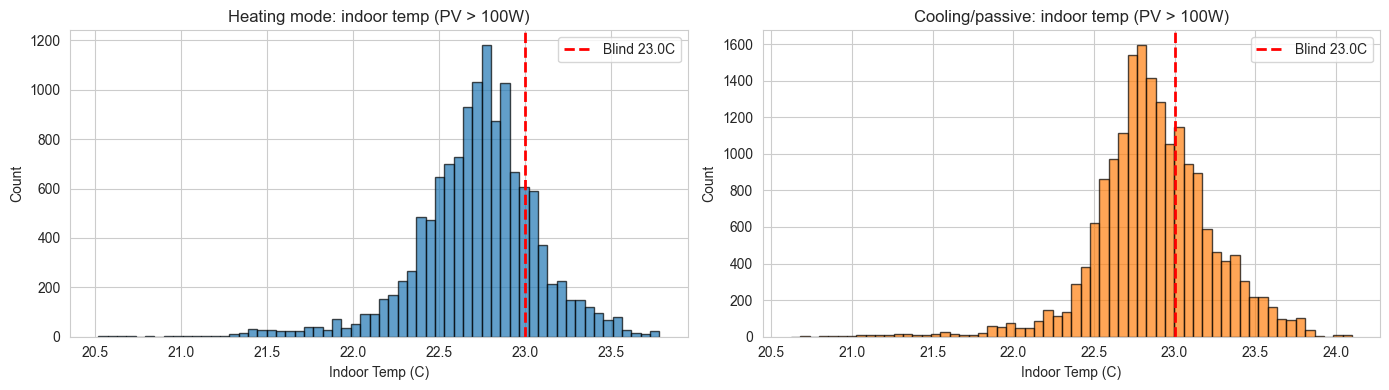

In [3]:
# === PHASE A — Cell 3: Sun positions + physics solar + merge + blind segmentation ===

print("Computing sun positions via astral...")
elev_arr = np.zeros(len(solar_df))
azim_arr = np.zeros(len(solar_df))
for i, ts in enumerate(solar_df.index):
    dt = ts.to_pydatetime()
    if dt.tzinfo is None:
        dt = TZ.localize(dt)
    try:
        elev_arr[i] = sun_elevation(OBSERVER, dt)
        azim_arr[i] = sun_azimuth(OBSERVER, dt)
    except Exception:
        elev_arr[i] = 0.0
        azim_arr[i] = 180.0

solar_df["sun_elevation"] = elev_arr
solar_df["sun_azimuth"] = azim_arr
solar_df["sun_elevation_rad"] = np.radians(np.clip(elev_arr, 0, 90))

# --- Physics solar models ---
def compute_physics_solar(sun_elev_rad, sun_azim_deg, ghi, cloud_pct, dni_meteo, dhi_meteo):
    n = len(ghi)
    sin_elev = np.sin(sun_elev_rad)
    cos_elev = np.cos(sun_elev_rad)
    az_rad = np.radians(sun_azim_deg)
    MIN_SIN = np.sin(np.radians(5.0))
    ERBS_MIN_SIN = np.sin(np.radians(10.0))
    sun_up = sin_elev > MIN_SIN
    erbs_valid = sin_elev > ERBS_MIN_SIN

    air_mass = np.where(sun_up, 1.0 / np.clip(sin_elev, MIN_SIN, 1.0), 0.0)
    clear_sky_dni = np.where(sun_up, 1361.0 * (0.7 ** (air_mass ** 0.678)), 0.0)
    cloud_frac = np.clip(cloud_pct / 100.0, 0, 1)
    kasten_factor = 1.0 - 0.75 * (cloud_frac ** 3.4)
    kasten_dni = clear_sky_dni * kasten_factor
    kasten_dhi = np.where(sun_up, clear_sky_dni * sin_elev * 0.1 * (1 + 2.0 * cloud_frac), 0.0)

    I0_h = np.where(erbs_valid, 1361.0 * sin_elev, 0.001)
    kT = np.where(erbs_valid, np.clip(ghi / np.clip(I0_h, 1.0, None), 0, 1), 0.0)
    kd = np.where(
        kT <= 0.22, 1.0 - 0.09 * kT,
        np.where(kT <= 0.80,
                 0.9511 - 0.1604*kT + 4.388*kT**2 - 16.638*kT**3 + 12.336*kT**4,
                 0.165))
    erbs_dhi = np.where(erbs_valid, kd * ghi, 0.0)
    erbs_dni = np.where(erbs_valid, (ghi - erbs_dhi) / np.clip(sin_elev, ERBS_MIN_SIN, 1.0), 0.0)
    erbs_dni = np.clip(erbs_dni, 0, 900)

    meteo_dni = np.clip(dni_meteo, 0, 1000)
    meteo_dhi = np.clip(dhi_meteo, 0, 500)

    def directional_gains(dni, dhi, mask):
        beam_v = np.where(mask, dni * cos_elev, 0.0)
        south = np.clip(np.where(mask, beam_v * np.clip(-np.cos(az_rad), 0, 1), 0.0), 0, 800)
        east = np.clip(np.where(mask, beam_v * np.clip(np.sin(az_rad), 0, 1), 0.0), 0, 800)
        west = np.clip(np.where(mask, beam_v * np.clip(-np.sin(az_rad), 0, 1), 0.0), 0, 800)
        diff_wall = np.where(mask, dhi * 0.5, 0.0)
        total = (south + east + west) + 3 * diff_wall
        return total

    return {
        "naive_ghi": ghi,
        "kasten_total": directional_gains(kasten_dni, kasten_dhi, sun_up),
        "erbs_total": directional_gains(erbs_dni, erbs_dhi, erbs_valid),
        "meteo_total": directional_gains(meteo_dni, meteo_dhi, sun_up),
    }

results = compute_physics_solar(
    solar_df["sun_elevation_rad"].values, solar_df["sun_azimuth"].values,
    solar_df["ghi_wm2"].values, solar_df["cloud_cover"].values,
    solar_df["dni_wm2"].values, solar_df["dhi_wm2"].values,
)
for key, val in results.items():
    solar_df[key] = val

solar_df["doy"] = solar_df.index.dayofyear
solar_df["hour_of_day"] = solar_df.index.hour

# --- Merge into both heating and cooling datasets ---
SOLAR_MODELS = ["naive_ghi", "kasten_total", "erbs_total", "meteo_total"]
merge_cols = SOLAR_MODELS + ["sun_elevation", "sun_azimuth", "ghi_wm2", "dni_wm2", "dhi_wm2"]
solar_hourly = solar_df.groupby(["doy", "hour_of_day"])[merge_cols].mean().reset_index()

denom = OE_LOCKED + HLC_LOCKED
exp_factor = 1.0 - np.exp(-DT_H / max(TAU_LOCKED, 0.1))

# Merge heating data
df_m_heat = df_heat.merge(
    solar_hourly, left_on=["doy_approx", "hour_approx"],
    right_on=["doy", "hour_of_day"], how="left"
)
for c in merge_cols:
    df_m_heat[c] = df_m_heat[c].fillna(0)

# Merge cooling data
df_m_cool = df_cool.merge(
    solar_hourly, left_on=["doy_approx", "hour_approx"],
    right_on=["doy", "hour_of_day"], how="left"
)
for c in merge_cols:
    df_m_cool[c] = df_m_cool[c].fillna(0)

print(f"Merged heating data: {len(df_m_heat)} rows")
print(f"Merged cooling/passive data: {len(df_m_cool)} rows")

# --- Blind segmentation (heating) ---
df_m_heat["pv_active"] = df_m_heat[PV_COL] > MIN_PV_POWER
df_m_heat["blind_closed"] = df_m_heat["indoor_temp"] >= BLIND_THRESHOLD

seg_heat_open = df_m_heat[df_m_heat["pv_active"] & ~df_m_heat["blind_closed"]]
seg_heat_closed = df_m_heat[df_m_heat["pv_active"] & df_m_heat["blind_closed"]]
seg_heat_night = df_m_heat[~df_m_heat["pv_active"]]

# --- Blind segmentation (cooling) ---
df_m_cool["pv_active"] = df_m_cool[PV_COL] > MIN_PV_POWER
df_m_cool["blind_closed"] = df_m_cool["indoor_temp"] >= BLIND_THRESHOLD

seg_cool_open = df_m_cool[df_m_cool["pv_active"] & ~df_m_cool["blind_closed"]]
seg_cool_closed = df_m_cool[df_m_cool["pv_active"] & df_m_cool["blind_closed"]]

print(f"\n=== Blind Segmentation (threshold = {BLIND_THRESHOLD}°C) ===")
print(f"--- HEATING MODE ---")
print(f"  PV active, blind OPEN:   {len(seg_heat_open):6d} rows ({100*len(seg_heat_open)/max(len(df_m_heat),1):.1f}%)")
print(f"  PV active, blind CLOSED: {len(seg_heat_closed):6d} rows ({100*len(seg_heat_closed)/max(len(df_m_heat),1):.1f}%)")
print(f"  Night / low PV:          {len(seg_heat_night):6d} rows ({100*len(seg_heat_night)/max(len(df_m_heat),1):.1f}%)")
print(f"--- COOLING/PASSIVE MODE ---")
print(f"  PV active, blind OPEN:   {len(seg_cool_open):6d} rows ({100*len(seg_cool_open)/max(len(df_m_cool),1):.1f}%)")
print(f"  PV active, blind CLOSED: {len(seg_cool_closed):6d} rows ({100*len(seg_cool_closed)/max(len(df_m_cool),1):.1f}%)")

# Indoor temp histogram when PV active
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.hist(df_m_heat.loc[df_m_heat["pv_active"], "indoor_temp"], bins=60, edgecolor="k", alpha=0.7)
ax1.axvline(BLIND_THRESHOLD, color="red", ls="--", lw=2, label=f"Blind {BLIND_THRESHOLD}C")
ax1.set_xlabel("Indoor Temp (C)"); ax1.set_ylabel("Count")
ax1.set_title("Heating mode: indoor temp (PV > 100W)"); ax1.legend()

ax2.hist(df_m_cool.loc[df_m_cool["pv_active"], "indoor_temp"], bins=60, edgecolor="k", alpha=0.7, color="tab:orange")
ax2.axvline(BLIND_THRESHOLD, color="red", ls="--", lw=2, label=f"Blind {BLIND_THRESHOLD}C")
ax2.set_xlabel("Indoor Temp (C)"); ax2.set_ylabel("Count")
ax2.set_title("Cooling/passive: indoor temp (PV > 100W)"); ax2.legend()
plt.tight_layout(); plt.show()

## Phase B — HP Equilibrium Residuals

In [4]:
# === PHASE B — HP-only equilibrium prediction & residuals ===

# T_eq (HP only, no solar) = (OE × T_outlet + HLC × T_outdoor) / (OE + HLC)
df_m_heat["T_eq_hp_only"] = (OE_LOCKED * df_m_heat["VLT"] + HLC_LOCKED * df_m_heat["AT"]) / denom
df_m_heat["residual"] = df_m_heat["indoor_temp"] - df_m_heat["T_eq_hp_only"]

df_m_cool["T_eq_hp_only"] = (OE_LOCKED * df_m_cool["VLT"] + HLC_LOCKED * df_m_cool["AT"]) / denom
df_m_cool["residual"] = df_m_cool["indoor_temp"] - df_m_cool["T_eq_hp_only"]

print("=== Equilibrium Residuals ===")
print(f"\n--- HEATING MODE ---")
print(f"  T_eq mean:     {df_m_heat['T_eq_hp_only'].mean():.2f}°C")
print(f"  Indoor mean:   {df_m_heat['indoor_temp'].mean():.2f}°C")
print(f"  Residual mean: {df_m_heat['residual'].mean():.3f}°C")
print(f"  Residual std:  {df_m_heat['residual'].std():.3f}°C")

print(f"\n--- COOLING/PASSIVE MODE ---")
print(f"  T_eq mean:     {df_m_cool['T_eq_hp_only'].mean():.2f}°C")
print(f"  Indoor mean:   {df_m_cool['indoor_temp'].mean():.2f}°C")
print(f"  Residual mean: {df_m_cool['residual'].mean():.3f}°C")
print(f"  Residual std:  {df_m_cool['residual'].std():.3f}°C")

# Residual by segment
print(f"\n=== Residual by segment ===")
for name, seg_df, parent_df in [
    ("Heat blind OPEN", seg_heat_open, df_m_heat),
    ("Heat blind CLOSED", seg_heat_closed, df_m_heat),
    ("Heat night", seg_heat_night, df_m_heat),
    ("Cool blind OPEN", seg_cool_open, df_m_cool),
    ("Cool blind CLOSED", seg_cool_closed, df_m_cool),
]:
    idx = seg_df.index
    r = parent_df.loc[parent_df.index.isin(idx), "residual"]
    if len(r) > 0:
        print(f"  {name:22s}: mean={r.mean():+.3f}, std={r.std():.3f}, n={len(r)}")

=== Equilibrium Residuals ===

--- HEATING MODE ---
  T_eq mean:     24.82°C
  Indoor mean:   22.77°C
  Residual mean: -2.047°C
  Residual std:  1.569°C

--- COOLING/PASSIVE MODE ---
  T_eq mean:     22.03°C
  Indoor mean:   22.95°C
  Residual mean: 0.924°C
  Residual std:  0.693°C

=== Residual by segment ===
  Heat blind OPEN       : mean=-2.071, std=1.435, n=10563
  Heat blind CLOSED     : mean=-1.920, std=1.426, n=2375
  Heat night            : mean=-2.048, std=1.619, n=32610
  Cool blind OPEN       : mean=+0.734, std=0.624, n=12098
  Cool blind CLOSED     : mean=+0.739, std=0.596, n=6151


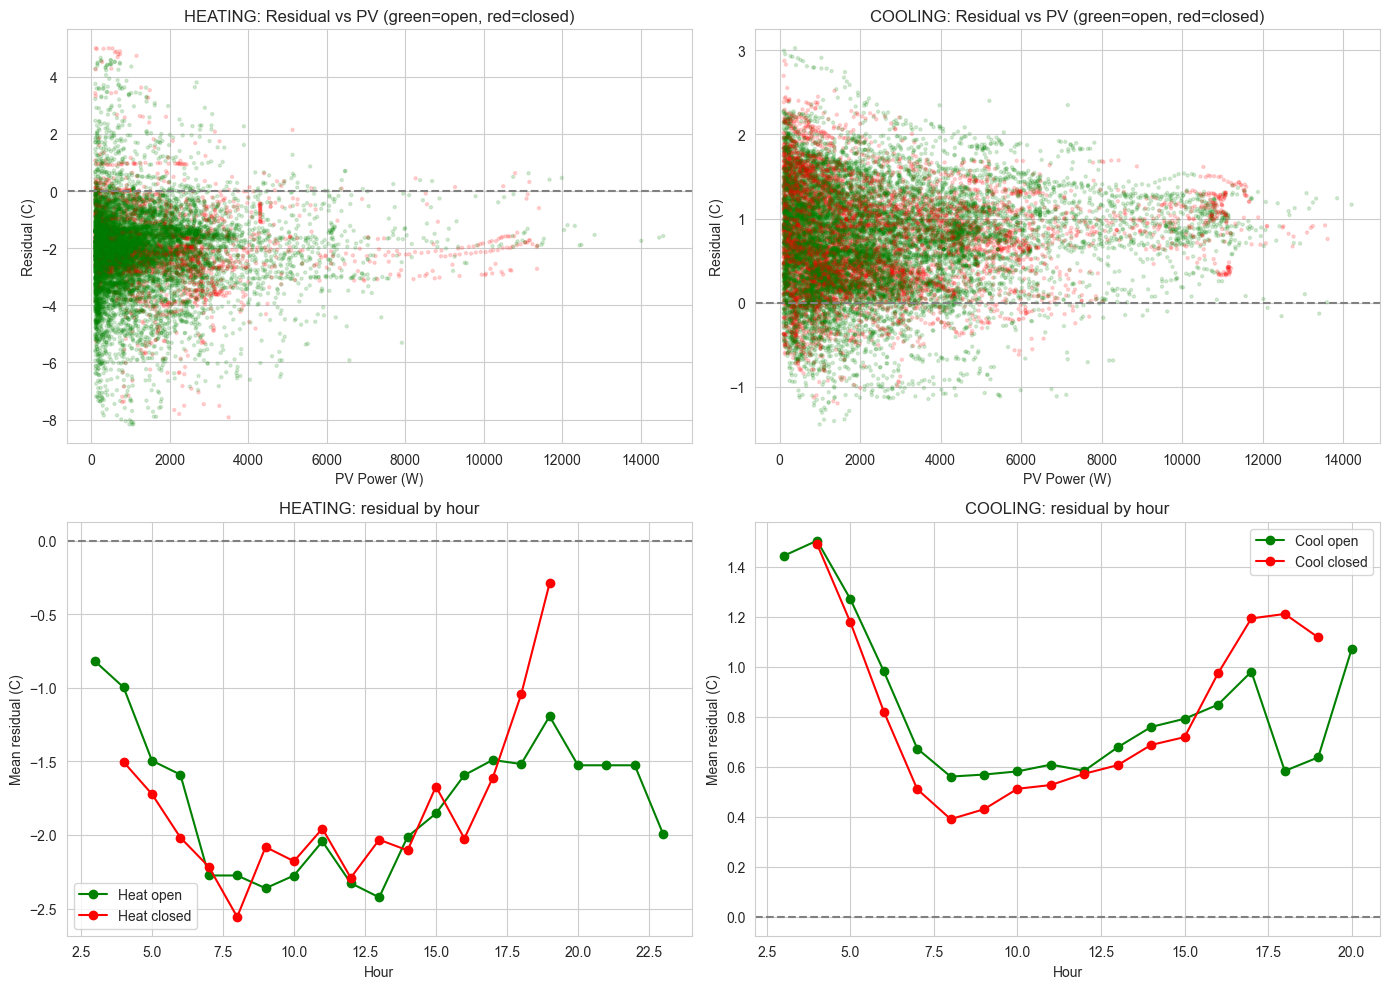

In [5]:
# === PHASE B — Residual visualization ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Residual vs PV (heating) colored by blind state
ax = axes[0, 0]
pv_rows = df_m_heat[df_m_heat["pv_active"]]
colors = np.where(pv_rows["blind_closed"], "red", "green")
ax.scatter(pv_rows[PV_COL], pv_rows["residual"], c=colors, alpha=0.15, s=5)
ax.axhline(0, color="gray", ls="--")
ax.set_xlabel("PV Power (W)"); ax.set_ylabel("Residual (C)")
ax.set_title("HEATING: Residual vs PV (green=open, red=closed)")

# (b) Residual vs PV (cooling) colored by blind state
ax = axes[0, 1]
pv_cool_rows = df_m_cool[df_m_cool["pv_active"]]
if len(pv_cool_rows) > 0:
    colors_c = np.where(pv_cool_rows["blind_closed"], "red", "green")
    ax.scatter(pv_cool_rows[PV_COL], pv_cool_rows["residual"], c=colors_c, alpha=0.15, s=5)
ax.axhline(0, color="gray", ls="--")
ax.set_xlabel("PV Power (W)"); ax.set_ylabel("Residual (C)")
ax.set_title("COOLING: Residual vs PV (green=open, red=closed)")

# (c) Residual vs hour (heating, by blind)
ax = axes[1, 0]
for name, seg, color in [("Heat open", seg_heat_open, "green"),
                          ("Heat closed", seg_heat_closed, "red")]:
    if len(seg) > 0:
        hourly = df_m_heat.loc[df_m_heat.index.isin(seg.index)].groupby("hour_approx")["residual"].mean()
        ax.plot(hourly.index, hourly.values, "o-", color=color, label=name)
ax.axhline(0, color="gray", ls="--")
ax.set_xlabel("Hour"); ax.set_ylabel("Mean residual (C)")
ax.set_title("HEATING: residual by hour"); ax.legend()

# (d) Residual vs hour (cooling, by blind)
ax = axes[1, 1]
for name, seg, color in [("Cool open", seg_cool_open, "green"),
                          ("Cool closed", seg_cool_closed, "red")]:
    if len(seg) > 0:
        hourly = df_m_cool.loc[df_m_cool.index.isin(seg.index)].groupby("hour_approx")["residual"].mean()
        ax.plot(hourly.index, hourly.values, "o-", color=color, label=name)
ax.axhline(0, color="gray", ls="--")
ax.set_xlabel("Hour"); ax.set_ylabel("Mean residual (C)")
ax.set_title("COOLING: residual by hour"); ax.legend()

plt.tight_layout(); plt.show()

## Phase C — Solar Weight Calibration

In [6]:
# === PHASE C — Cell 1: Equilibrium-residual OLS calibration ===
# Method: residual = a0 + solar_w × solar / denom

print("=" * 70)
print("EQUILIBRIUM-RESIDUAL CALIBRATION (with intercept)")
print("residual = a0 + solar_w × solar / denom")
print("=" * 70)

all_eq_results = []

for mode_name, segments in [
    ("HEATING", [
        ("Blind OPEN", seg_heat_open, df_m_heat),
        ("Blind CLOSED", seg_heat_closed, df_m_heat),
        ("All PV", df_m_heat[df_m_heat["pv_active"]], df_m_heat),
    ]),
    ("COOLING", [
        ("Blind OPEN", seg_cool_open, df_m_cool),
        ("Blind CLOSED", seg_cool_closed, df_m_cool),
        ("All PV", df_m_cool[df_m_cool["pv_active"]], df_m_cool),
    ]),
]:
    print(f"\n--- {mode_name} MODE ---")
    print(f"{'Regime':>12s} {'Model':>12s} {'a0 (bias)':>10s} {'solar_w':>10s} {'RMSE':>8s} {'N':>6s}")
    print("-" * 62)
    for regime_name, seg_data, parent_df in segments:
        if len(seg_data) < 50:
            print(f"{regime_name:>12s} (too few rows: {len(seg_data)})")
            continue
        for solar_col, model_name in [(PV_COL, "PV sensor"),
                                       ("naive_ghi", "GHI"),
                                       ("erbs_total", "Erbs dir."),
                                       ("meteo_total", "Meteo dir.")]:
            solar_vals = parent_df.loc[parent_df.index.isin(seg_data.index), solar_col].fillna(0).values / denom
            residual_vals = parent_df.loc[parent_df.index.isin(seg_data.index), "residual"].values
            X = np.column_stack([np.ones(len(residual_vals)), solar_vals])
            beta, _, _, _ = np.linalg.lstsq(X, residual_vals, rcond=None)
            pred = X @ beta
            rmse = np.sqrt(np.mean((pred - residual_vals)**2))
            print(f"{regime_name:>12s} {model_name:>12s} {beta[0]:>+10.3f} {beta[1]:>10.6f} {rmse:>8.4f} {len(residual_vals):>6d}")
            all_eq_results.append({
                "mode": mode_name, "regime": regime_name, "model": model_name,
                "a0_bias": beta[0], "solar_w": beta[1],
                "rmse": rmse, "n": len(residual_vals)
            })

all_eq_df = pd.DataFrame(all_eq_results)

# Show heating vs cooling comparison
print("\n--- HEATING vs COOLING solar_w (PV sensor, equilibrium-residual) ---")
for regime in ["Blind OPEN", "Blind CLOSED", "All PV"]:
    w_h = all_eq_df[(all_eq_df["mode"] == "HEATING") & (all_eq_df["regime"] == regime) & (all_eq_df["model"] == "PV sensor")]
    w_c = all_eq_df[(all_eq_df["mode"] == "COOLING") & (all_eq_df["regime"] == regime) & (all_eq_df["model"] == "PV sensor")]
    if len(w_h) > 0 and len(w_c) > 0:
        print(f"  {regime:>12s}: heating={w_h['solar_w'].values[0]:+.6f}, cooling={w_c['solar_w'].values[0]:.6f}")

EQUILIBRIUM-RESIDUAL CALIBRATION (with intercept)
residual = a0 + solar_w × solar / denom

--- HEATING MODE ---
      Regime        Model  a0 (bias)    solar_w     RMSE      N
--------------------------------------------------------------
  Blind OPEN    PV sensor     -2.098   0.000019   1.4347  10563
  Blind OPEN          GHI     -2.141   0.000550   1.4322  10563
  Blind OPEN    Erbs dir.     -2.107   0.000153   1.4341  10563
  Blind OPEN   Meteo dir.     -2.118   0.000184   1.4339  10563
Blind CLOSED    PV sensor     -1.825  -0.000049   1.4221   2375
Blind CLOSED          GHI     -2.072   0.000559   1.4209   2375
Blind CLOSED    Erbs dir.     -1.980   0.000115   1.4253   2375
Blind CLOSED   Meteo dir.     -1.912  -0.000015   1.4261   2375
      All PV    PV sensor     -2.046   0.000002   1.4346  12938
      All PV          GHI     -2.135   0.000598   1.4303  12938
      All PV    Erbs dir.     -2.095   0.000178   1.4331  12938
      All PV   Meteo dir.     -2.099   0.000179   1.4333 

In [7]:
# === PHASE C — Cell 2: Multivariate OLS calibration ===
# Model: dT(i) = a0 + a1*(VLT(i)-T(i-1)) + a2*(AT(i)-T(i-1)) + a3*solar(i)

def calibrate_solar_w_mvols(data, solar_col):
    """Multivariate OLS: isolate solar contribution from dT."""
    indoor = data["indoor_temp"].values.astype(np.float64)
    outdoor = data["AT"].values.astype(np.float64)
    vlt_v = data["VLT"].values.astype(np.float64)
    solar = data[solar_col].fillna(0).values.astype(np.float64)
    doy_v = data["doy_approx"].values

    dT = np.diff(indoor)
    same_day = doy_v[1:] == doy_v[:-1]
    dT = dT[same_day]
    vlt_s = vlt_v[1:][same_day]
    at_s = outdoor[1:][same_day]
    t_prev = indoor[:-1][same_day]
    sol_s = solar[1:][same_day]

    X = np.column_stack([
        np.ones(len(dT)),
        vlt_s - t_prev,
        at_s - t_prev,
        sol_s,
    ])
    beta, _, _, _ = np.linalg.lstsq(X, dT, rcond=None)
    pred = X @ beta
    rmse = np.sqrt(np.mean((pred - dT)**2))
    solar_w = beta[3] * denom / exp_factor
    return solar_w, rmse, beta, len(dT)

print("=" * 70)
print("MULTIVARIATE OLS CALIBRATION (per-step dT)")
print("Model: dT = a0 + a1*(VLT-T) + a2*(AT-T) + a3*solar")
print("=" * 70)

mvols_results = []
for mode_name, segments_list in [
    ("HEATING", [
        ("Blind OPEN", seg_heat_open),
        ("Blind CLOSED", seg_heat_closed),
        ("All PV", df_m_heat[df_m_heat["pv_active"]]),
    ]),
    ("COOLING", [
        ("Blind OPEN", seg_cool_open),
        ("Blind CLOSED", seg_cool_closed),
        ("All PV", df_m_cool[df_m_cool["pv_active"]]),
    ]),
]:
    print(f"\n--- {mode_name} MODE ---")
    for regime_name, seg_data in segments_list:
        if len(seg_data) < 100:
            print(f"  {regime_name}: too few rows ({len(seg_data)})")
            continue
        w, rmse, beta, n = calibrate_solar_w_mvols(seg_data, PV_COL)
        print(f"  {regime_name:>12s}: solar_w={w:.6f}, RMSE(dT)={rmse:.5f}, n={n}")
        print(f"    a0={beta[0]:.6f}, a1(VLT)={beta[1]:.6f}, a2(AT)={beta[2]:.6f}, a3(solar)={beta[3]:.9f}")
        mvols_results.append({
            "mode": mode_name, "regime": regime_name,
            "solar_w": w, "rmse": rmse, "n": n,
            "a0": beta[0], "a1_vlt": beta[1], "a2_at": beta[2], "a3_solar": beta[3]
        })

mvols_df = pd.DataFrame(mvols_results)
print("\n--- Summary ---")
print(mvols_df[["mode", "regime", "solar_w", "rmse", "n"]].to_string(index=False))

MULTIVARIATE OLS CALIBRATION (per-step dT)
Model: dT = a0 + a1*(VLT-T) + a2*(AT-T) + a3*solar

--- HEATING MODE ---
    Blind OPEN: solar_w=0.000161, RMSE(dT)=0.03887, n=10303
    a0=-0.005372, a1(VLT)=0.001215, a2(AT)=0.000094, a3(solar)=0.000002875
  Blind CLOSED: solar_w=0.000060, RMSE(dT)=0.02163, n=2249
    a0=0.003081, a1(VLT)=-0.000037, a2(AT)=0.000001, a3(solar)=0.000001077
        All PV: solar_w=0.000134, RMSE(dT)=0.04211, n=12643
    a0=-0.000017, a1(VLT)=0.000600, a2(AT)=0.000144, a3(solar)=0.000002401

--- COOLING MODE ---
    Blind OPEN: solar_w=0.000103, RMSE(dT)=0.03653, n=11806
    a0=-0.002527, a1(VLT)=0.007861, a2(AT)=0.000644, a3(solar)=0.000001840
  Blind CLOSED: solar_w=0.000034, RMSE(dT)=0.03187, n=5994
    a0=0.010019, a1(VLT)=0.003795, a2(AT)=0.000979, a3(solar)=0.000000600
        All PV: solar_w=0.000071, RMSE(dT)=0.04087, n=17928
    a0=0.004794, a1(VLT)=0.007602, a2(AT)=0.000977, a3(solar)=0.000001276

--- Summary ---
   mode       regime  solar_w     rmse 

HP COMPENSATION ANALYSIS

In heating mode (PV active, 12938 rows):
  Corr(PV, thermal_power) = 0.0231
  Corr(PV, VLT)           = -0.1302
  --> HP INCREASES output when PV is high (co-occurrence)

In cooling/passive mode (PV active, 18249 rows):
  Corr(PV, thermal_power) = -0.0507


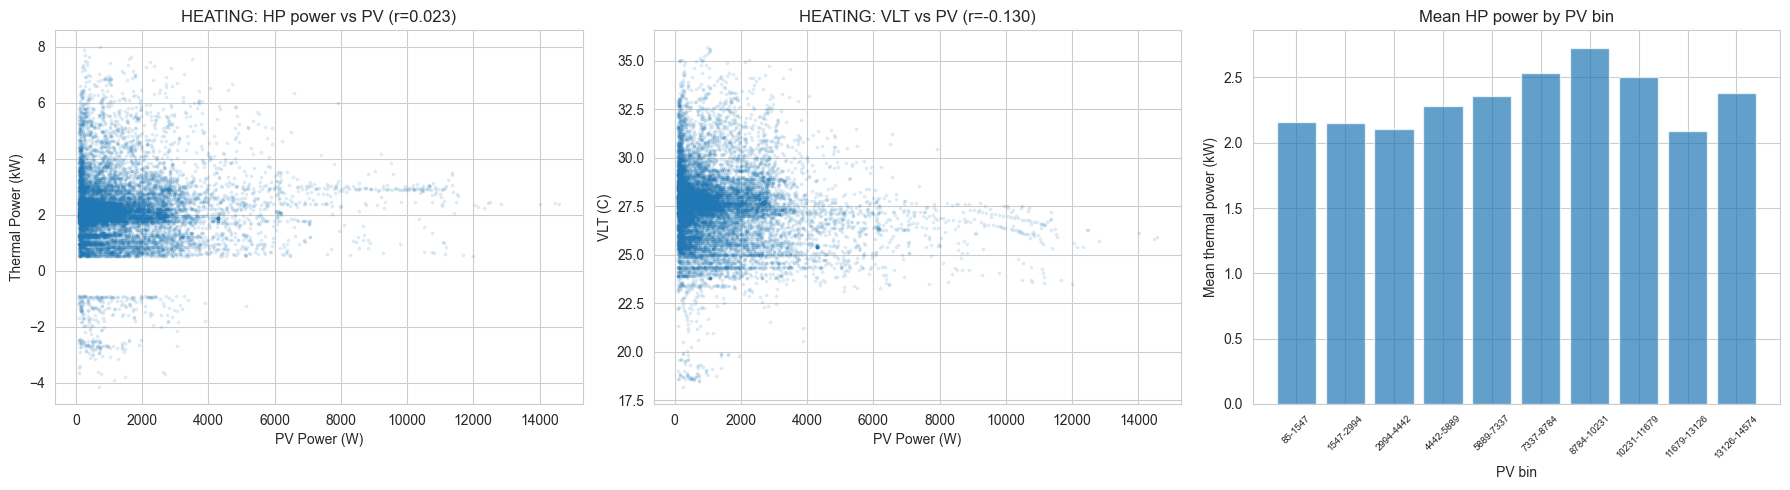

In [8]:
# === PHASE C — Cell 3: HP compensation analysis ===

print("=" * 70)
print("HP COMPENSATION ANALYSIS")
print("=" * 70)

# Correlation between PV and thermal power in heating mode
pv_heat_active = df_m_heat[df_m_heat["pv_active"]]
corr_tp = np.corrcoef(pv_heat_active[PV_COL], pv_heat_active["thermal_power_kw"])[0, 1]
corr_vlt = np.corrcoef(pv_heat_active[PV_COL], pv_heat_active["VLT"])[0, 1]
print(f"\nIn heating mode (PV active, {len(pv_heat_active)} rows):")
print(f"  Corr(PV, thermal_power) = {corr_tp:.4f}")
print(f"  Corr(PV, VLT)           = {corr_vlt:.4f}")
if corr_tp < 0:
    print(f"  --> HP REDUCES output when PV is high (compensation!)")
elif corr_tp > 0:
    print(f"  --> HP INCREASES output when PV is high (co-occurrence)")

# Same for cooling data
pv_cool_active = df_m_cool[df_m_cool["pv_active"]]
if len(pv_cool_active) > 30:
    corr_cool = np.corrcoef(pv_cool_active[PV_COL], pv_cool_active["thermal_power_kw"])[0, 1]
    print(f"\nIn cooling/passive mode (PV active, {len(pv_cool_active)} rows):")
    print(f"  Corr(PV, thermal_power) = {corr_cool:.4f}")

# Visual: thermal power vs PV
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax = axes[0]
ax.scatter(pv_heat_active[PV_COL], pv_heat_active["thermal_power_kw"], alpha=0.1, s=3)
ax.set_xlabel("PV Power (W)"); ax.set_ylabel("Thermal Power (kW)")
ax.set_title(f"HEATING: HP power vs PV (r={corr_tp:.3f})")

ax = axes[1]
ax.scatter(pv_heat_active[PV_COL], pv_heat_active["VLT"], alpha=0.1, s=3)
ax.set_xlabel("PV Power (W)"); ax.set_ylabel("VLT (C)")
ax.set_title(f"HEATING: VLT vs PV (r={corr_vlt:.3f})")

ax = axes[2]
pv_bins = pd.cut(pv_heat_active[PV_COL], bins=10)
tp_by_pv = pv_heat_active.groupby(pv_bins, observed=True)["thermal_power_kw"].mean()
ax.bar(range(len(tp_by_pv)), tp_by_pv.values, alpha=0.7)
ax.set_xlabel("PV bin"); ax.set_ylabel("Mean thermal power (kW)")
ax.set_title("Mean HP power by PV bin")
ax.set_xticks(range(len(tp_by_pv)))
ax.set_xticklabels([f"{int(i.left)}-{int(i.right)}" for i in tp_by_pv.index], rotation=45, fontsize=7)
plt.tight_layout(); plt.show()

## Phase D — Sun-Angle Analysis

SUN-ANGLE ANALYSIS BY MODE

--- HEATING MODE (blind-open, sun > 5deg): 7988 rows ---
   Elevation     Med w_PV    Med w_GHI   Mean res      N
-------------------------------------------------------
     5-15deg    -0.002411    -0.205265     -2.144   2619
    15-25deg    -0.002060    -0.017460     -2.242   3094
    25-35deg    -0.001522    -0.008892     -2.028   1178
    35-45deg    -0.000858    -0.006139     -1.945    563
    45-55deg    -0.000492    -0.003578     -1.564    299
    55-65deg    -0.000479    -0.003388     -1.300    235

--- COOLING MODE (blind-open, sun > 5deg): 9167 rows ---
   Elevation     Med w_PV    Med w_GHI   Mean res      N
-------------------------------------------------------
     5-15deg     0.000300     0.011720     +0.664   2130
    15-25deg     0.000241     0.003217     +0.562   2628
    25-35deg     0.000210     0.001903     +0.624   2398
    35-45deg     0.000202     0.001727     +0.932   1151
    45-55deg     0.000187     0.001761     +0.897    654
    

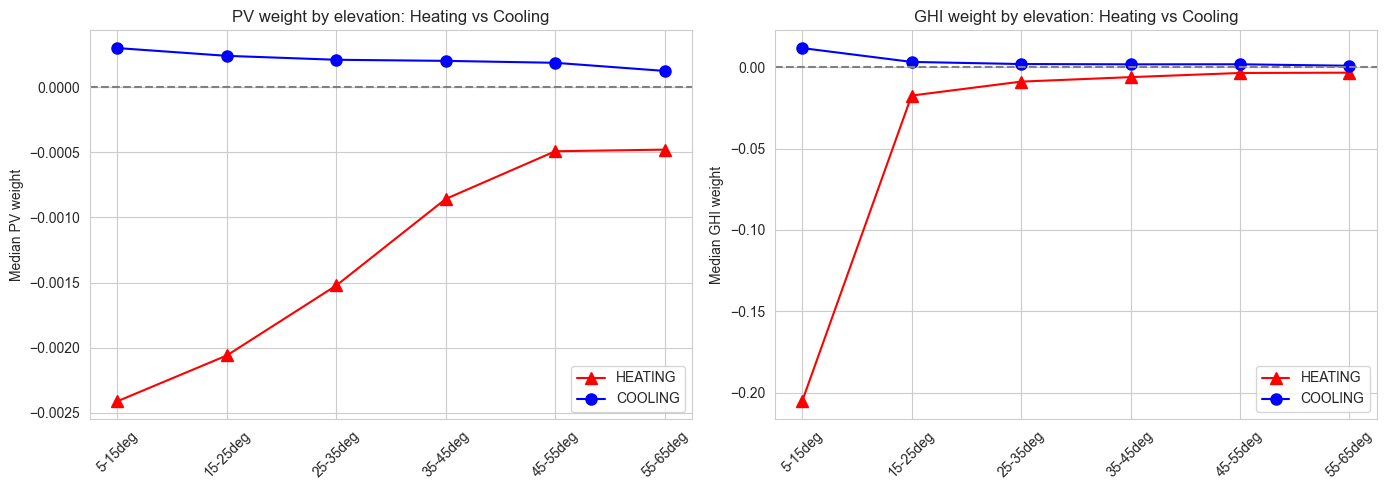

In [9]:
# === PHASE D — Cell 1: Elevation-bin analysis ===
# Compare elevation-dependent weights from heating vs cooling data

ELEV_BINS = [5, 15, 25, 35, 45, 55, 65]
ELEV_LABELS = [f"{ELEV_BINS[i]}-{ELEV_BINS[i+1]}deg" for i in range(len(ELEV_BINS)-1)]
AZ_BINS = [(60, 120, "East"), (120, 240, "South"), (240, 300, "West")]

print("=" * 70)
print("SUN-ANGLE ANALYSIS BY MODE")
print("=" * 70)

elev_results = []

for mode_name, pv_data, parent_df in [
    ("HEATING", seg_heat_open, df_m_heat),
    ("COOLING", seg_cool_open, df_m_cool),
]:
    sun_data = parent_df.loc[
        parent_df.index.isin(pv_data.index) & (parent_df["sun_elevation"] > 5)
    ].copy()
    sun_data["eff_weight_pv"] = sun_data["residual"] / sun_data[PV_COL].clip(lower=1)
    sun_data["eff_weight_ghi"] = sun_data["residual"] / sun_data["naive_ghi"].clip(lower=1)
    sun_data["elev_bin"] = pd.cut(sun_data["sun_elevation"], bins=ELEV_BINS, labels=ELEV_LABELS)
    
    print(f"\n--- {mode_name} MODE (blind-open, sun > 5deg): {len(sun_data)} rows ---")
    print(f"{'Elevation':>12s} {'Med w_PV':>12s} {'Med w_GHI':>12s} {'Mean res':>10s} {'N':>6s}")
    print("-" * 55)
    for label in ELEV_LABELS:
        subset = sun_data[sun_data["elev_bin"] == label]
        if len(subset) < 10:
            print(f"{label:>12s} {'n/a':>12s} {'n/a':>12s} {'n/a':>10s} {len(subset):>6d}")
            continue
        med_pv = subset["eff_weight_pv"].median()
        med_ghi = subset["eff_weight_ghi"].median()
        mean_res = subset["residual"].mean()
        print(f"{label:>12s} {med_pv:>12.6f} {med_ghi:>12.6f} {mean_res:>+10.3f} {len(subset):>6d}")
        elev_results.append({
            "mode": mode_name, "elev_bin": label,
            "w_pv": med_pv, "w_ghi": med_ghi, "mean_res": mean_res, "n": len(subset)
        })

elev_all_df = pd.DataFrame(elev_results)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for mode_name, color, marker in [("HEATING", "red", "^"), ("COOLING", "blue", "o")]:
    sub = elev_all_df[elev_all_df["mode"] == mode_name]
    if len(sub) > 0:
        ax1.plot(range(len(sub)), sub["w_pv"].values, f"{marker}-", color=color, label=mode_name, markersize=8)
        ax2.plot(range(len(sub)), sub["w_ghi"].values, f"{marker}-", color=color, label=mode_name, markersize=8)

heat_labels = elev_all_df[elev_all_df["mode"] == "HEATING"]["elev_bin"].values
cool_labels = elev_all_df[elev_all_df["mode"] == "COOLING"]["elev_bin"].values
labels = heat_labels if len(heat_labels) >= len(cool_labels) else cool_labels

ax1.set_xticks(range(len(labels))); ax1.set_xticklabels(labels, rotation=45)
ax1.set_ylabel("Median PV weight"); ax1.set_title("PV weight by elevation: Heating vs Cooling")
ax1.axhline(0, color="gray", ls="--"); ax1.legend()

ax2.set_xticks(range(len(labels))); ax2.set_xticklabels(labels, rotation=45)
ax2.set_ylabel("Median GHI weight"); ax2.set_title("GHI weight by elevation: Heating vs Cooling")
ax2.axhline(0, color="gray", ls="--"); ax2.legend()

plt.tight_layout(); plt.show()

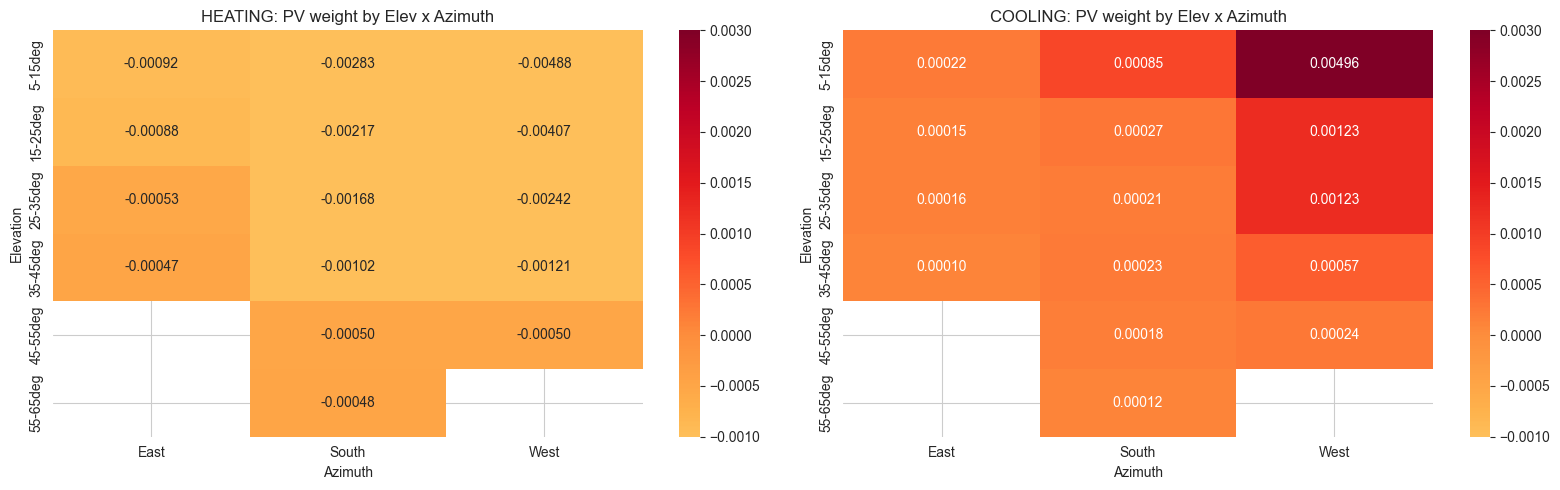

In [10]:
# === PHASE D — Cell 2: Azimuth heatmap (both modes) ===

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_idx, (mode_name, pv_data, parent_df) in enumerate([
    ("HEATING", seg_heat_open, df_m_heat),
    ("COOLING", seg_cool_open, df_m_cool),
]):
    sun_data = parent_df.loc[
        parent_df.index.isin(pv_data.index) & (parent_df["sun_elevation"] > 5)
    ].copy()
    sun_data["eff_weight_pv"] = sun_data["residual"] / sun_data[PV_COL].clip(lower=1)
    sun_data["elev_bin"] = pd.cut(sun_data["sun_elevation"], bins=ELEV_BINS, labels=ELEV_LABELS)
    
    angle_data = []
    for elev_label in ELEV_LABELS:
        row = {"elev_bin": elev_label}
        for az_lo, az_hi, az_name in AZ_BINS:
            mask = ((sun_data["elev_bin"] == elev_label) &
                    (sun_data["sun_azimuth"] >= az_lo) & (sun_data["sun_azimuth"] < az_hi))
            subset = sun_data[mask]
            row[az_name] = subset["eff_weight_pv"].median() if len(subset) >= 10 else float("nan")
        angle_data.append(row)
    
    adf = pd.DataFrame(angle_data)
    heat_matrix = adf.set_index("elev_bin")[["East", "South", "West"]]
    ax = axes[ax_idx]
    sns.heatmap(heat_matrix, annot=True, fmt=".5f", cmap="YlOrRd", ax=ax,
                center=0, vmin=-0.001, vmax=0.003)
    ax.set_title(f"{mode_name}: PV weight by Elev x Azimuth")
    ax.set_ylabel("Elevation"); ax.set_xlabel("Azimuth")

plt.tight_layout(); plt.show()

In [12]:
# === PHASE D — Cell 3: Correction method comparison (both modes) ===

print("=" * 70)
print("CORRECTION METHOD COMPARISON")
print("=" * 70)

def build_luts_and_evaluate(pv_data, parent_df, eval_pv_data, eval_parent_df, mode_label):
    """Build LUTs from calibration data, evaluate on eval data."""
    # Prep calibration data
    cal = parent_df.loc[parent_df.index.isin(pv_data.index) & (parent_df["sun_elevation"] > 5)].copy()
    cal["eff_weight_pv"] = cal["residual"] / cal[PV_COL].clip(lower=1)
    cal["elev_bin"] = pd.cut(cal["sun_elevation"], bins=ELEV_BINS, labels=ELEV_LABELS)
    
    # Build LUTs
    hour_lut = {}
    for h in range(24):
        subset = cal[cal["hour_approx"] == h]
        hour_lut[h] = subset["eff_weight_pv"].median() if len(subset) >= 10 else 0.0
    
    elev_lut = {}
    for label in ELEV_LABELS:
        subset = cal[cal["elev_bin"] == label]
        elev_lut[label] = subset["eff_weight_pv"].median() if len(subset) >= 10 else 0.0
    
    elev_az_lut = {}
    for elev_label in ELEV_LABELS:
        for az_lo, az_hi, az_name in AZ_BINS:
            mask = ((cal["elev_bin"] == elev_label) &
                    (cal["sun_azimuth"] >= az_lo) & (cal["sun_azimuth"] < az_hi))
            subset = cal[mask]
            elev_az_lut[(elev_label, az_name)] = subset["eff_weight_pv"].median() if len(subset) >= 10 else elev_lut.get(elev_label, 0.0)
    
    # Single weight from eq-residual OLS
    solar_v = cal[PV_COL].fillna(0).values / denom
    X = np.column_stack([np.ones(len(solar_v)), solar_v])
    beta, _, _, _ = np.linalg.lstsq(X, cal["residual"].values, rcond=None)
    w_single = max(0.0, beta[1])
    
    # Evaluate
    ev = eval_parent_df.loc[
        eval_parent_df.index.isin(eval_pv_data.index) & (eval_parent_df["sun_elevation"] > 5)
    ].copy()
    ev["elev_bin"] = pd.cut(ev["sun_elevation"], bins=ELEV_BINS, labels=ELEV_LABELS)
    
    if len(ev) < 50:
        print(f"  {mode_label}: too few eval rows ({len(ev)})")
        return {}
    
    methods = {}
    # A: Single weight
    pred_A = w_single * ev[PV_COL]
    methods["A: Single weight"] = np.sqrt(np.mean((pred_A - ev["residual"])**2))
    
    # B: Dual weight (blind)
    w_open_cal = max(0.0, beta[1])
    cal_closed = parent_df.loc[
        parent_df.index.isin(
            parent_df[(parent_df["pv_active"]) & (parent_df["blind_closed"]) & (parent_df["sun_elevation"] > 5)].index
        )
    ]
    if len(cal_closed) > 50:
        sv_c = cal_closed[PV_COL].fillna(0).values / denom
        Xc = np.column_stack([np.ones(len(sv_c)), sv_c])
        beta_c, _, _, _ = np.linalg.lstsq(Xc, cal_closed["residual"].values, rcond=None)
        w_closed_cal = max(0.0, beta_c[1])
    else:
        w_closed_cal = w_open_cal * 0.5
    w_dual = np.where(ev["blind_closed"], w_closed_cal, w_open_cal)
    pred_B = w_dual * ev[PV_COL]
    methods["B: Dual (blind)"] = np.sqrt(np.mean((pred_B - ev["residual"])**2))
    
    # C: Hour-of-day LUT
    pred_C = ev["hour_approx"].map(hour_lut).fillna(0) * ev[PV_COL]
    methods["C: Hour LUT (24)"] = np.sqrt(np.mean((pred_C - ev["residual"])**2))
    
    # D: Elevation LUT — convert categorical to float via map
    pred_D = ev["elev_bin"].astype(str).map(elev_lut).fillna(0).astype(float) * ev[PV_COL]
    methods["D: Elev (6 bins)"] = np.sqrt(np.mean((pred_D - ev["residual"])**2))
    
    # E: Elevation x Azimuth LUT
    def get_elev_az_w(row):
        az = row["sun_azimuth"]
        az_name = "South"
        for lo, hi, name in AZ_BINS:
            if lo <= az < hi:
                az_name = name; break
        eb = str(row["elev_bin"]) if pd.notna(row.get("elev_bin")) else ""
        return elev_az_lut.get((eb, az_name), 0.0)
    pred_E = ev.apply(get_elev_az_w, axis=1) * ev[PV_COL]
    methods["E: Elev x Az (18)"] = np.sqrt(np.mean((pred_E - ev["residual"])**2))
    
    print(f"\n--- {mode_label} (cal={len(cal)}, eval={len(ev)}) ---")
    print(f"  w_single={w_single:.6f}, w_closed={w_closed_cal:.6f}")
    print(f"  {'Method':>25s}  {'RMSE':>8s}  {'vs A':>8s}")
    print("  " + "-" * 45)
    baseline = methods["A: Single weight"]
    for name, rmse_val in sorted(methods.items(), key=lambda x: x[1]):
        print(f"  {name:>25s}  {rmse_val:8.4f}  {rmse_val - baseline:+8.4f}")
    
    return methods

# Heating: calibrate on heating, evaluate on heating
heat_methods = build_luts_and_evaluate(
    seg_heat_open, df_m_heat, seg_heat_open, df_m_heat, "HEATING (self-eval)")

# Cooling: calibrate on cooling, evaluate on cooling
cool_methods = build_luts_and_evaluate(
    seg_cool_open, df_m_cool, seg_cool_open, df_m_cool, "COOLING (self-eval)")

# Cross: calibrate on cooling, evaluate on heating
cross_methods = build_luts_and_evaluate(
    seg_cool_open, df_m_cool, seg_heat_open, df_m_heat, "CROSS (cal=cool, eval=heat)")

CORRECTION METHOD COMPARISON

--- HEATING (self-eval) (cal=7988, eval=7988) ---
  w_single=0.000021, w_closed=0.000000
                     Method      RMSE      vs A
  ---------------------------------------------
          E: Elev x Az (18)    2.3914   -0.1759
           A: Single weight    2.5673   +0.0000
            B: Dual (blind)    2.5673   +0.0000
           D: Elev (6 bins)    2.6021   +0.0348
           C: Hour LUT (24)    3.3633   +0.7959

--- COOLING (self-eval) (cal=9167, eval=9167) ---
  w_single=0.000032, w_closed=0.000005
                     Method      RMSE      vs A
  ---------------------------------------------
          E: Elev x Az (18)    0.7181   -0.0906
           D: Elev (6 bins)    0.7380   -0.0708
           C: Hour LUT (24)    0.7769   -0.0319
           A: Single weight    0.8088   +0.0000
            B: Dual (blind)    0.8088   +0.0000

--- CROSS (cal=cool, eval=heat) (cal=9167, eval=7988) ---
  w_single=0.000032, w_closed=0.000005
                     

In [ ]:
# === PHASE D-bis: BIAS-CORRECTED Correction Method Comparison ===
# The -2°C heating bias overwhelms angle corrections.
# Fix: subtract the mode-specific a0 intercept from residuals before evaluation.
# This simulates what the model would look like AFTER joint recalibration (Priority 4).

print("=" * 70)
print("BIAS-CORRECTED CORRECTION METHOD COMPARISON")
print("residual_bc = residual - a0_bias  (removes mode-specific offset)")
print("=" * 70)

# Get a0 biases from the eq-residual OLS (PV sensor, blind-open)
heat_a0 = all_eq_df[
    (all_eq_df["mode"] == "HEATING") & (all_eq_df["regime"] == "Blind OPEN") & (all_eq_df["model"] == "PV sensor")
]["a0_bias"].values[0]
cool_a0 = all_eq_df[
    (all_eq_df["mode"] == "COOLING") & (all_eq_df["regime"] == "Blind OPEN") & (all_eq_df["model"] == "PV sensor")
]["a0_bias"].values[0]
print(f"\nBias corrections: heating a0 = {heat_a0:+.3f}°C, cooling a0 = {cool_a0:+.3f}°C")

# Create bias-corrected residuals
df_m_heat["residual_bc"] = df_m_heat["residual"] - heat_a0
df_m_cool["residual_bc"] = df_m_cool["residual"] - cool_a0
print(f"After correction:")
print(f"  Heating residual_bc mean: {df_m_heat['residual_bc'].mean():.3f}°C (was {df_m_heat['residual'].mean():.3f})")
print(f"  Cooling residual_bc mean: {df_m_cool['residual_bc'].mean():.3f}°C (was {df_m_cool['residual'].mean():.3f})")

def build_luts_and_evaluate_bc(pv_seg, parent, ev_seg, ev_parent, label):
    """Build LUTs from bias-corrected residuals and evaluate."""
    cal = parent.loc[parent.index.isin(pv_seg.index) & (parent["sun_elevation"] > 5)].copy()
    cal["ew"] = cal["residual_bc"] / cal[PV_COL].clip(lower=1)
    cal["elev_bin"] = pd.cut(cal["sun_elevation"], bins=ELEV_BINS, labels=ELEV_LABELS)

    hour_lut = {}
    for hh in range(24):
        s = cal[cal["hour_approx"] == hh]
        hour_lut[hh] = s["ew"].median() if len(s) >= 10 else 0.0

    elev_lut = {}
    for lb in ELEV_LABELS:
        s = cal[cal["elev_bin"] == lb]
        elev_lut[lb] = s["ew"].median() if len(s) >= 10 else 0.0

    elev_az_lut = {}
    for el in ELEV_LABELS:
        for alo, ahi, anm in AZ_BINS:
            s = cal[(cal["elev_bin"] == el) & (cal["sun_azimuth"] >= alo) & (cal["sun_azimuth"] < ahi)]
            elev_az_lut[(el, anm)] = s["ew"].median() if len(s) >= 10 else elev_lut.get(el, 0.0)

    sv = cal[PV_COL].fillna(0).values / denom
    X = np.column_stack([np.ones(len(sv)), sv])
    beta, _, _, _ = np.linalg.lstsq(X, cal["residual_bc"].values, rcond=None)
    ws = max(0.0, beta[1])

    ev = ev_parent.loc[ev_parent.index.isin(ev_seg.index) & (ev_parent["sun_elevation"] > 5)].copy()
    ev["elev_bin"] = pd.cut(ev["sun_elevation"], bins=ELEV_BINS, labels=ELEV_LABELS)
    if len(ev) < 50:
        print(f"  {label}: too few eval rows ({len(ev)})")
        return {}
    tgt = ev["residual_bc"].values

    # Closed-blind weight
    cc = parent.loc[(parent["pv_active"]) & (parent["blind_closed"]) & (parent["sun_elevation"] > 5)]
    if len(cc) > 50:
        svc = cc[PV_COL].fillna(0).values / denom
        Xc = np.column_stack([np.ones(len(svc)), svc])
        bc2, _, _, _ = np.linalg.lstsq(Xc, cc["residual_bc"].values, rcond=None)
        wc = max(0.0, bc2[1])
    else:
        wc = ws * 0.5

    m = {}
    m["A: Single weight"] = np.sqrt(np.mean((ws * ev[PV_COL].values - tgt)**2))
    m["B: Dual (blind)"] = np.sqrt(np.mean((np.where(ev["blind_closed"].values, wc, ws) * ev[PV_COL].values - tgt)**2))
    m["C: Hour LUT (24)"] = np.sqrt(np.mean((ev["hour_approx"].map(hour_lut).fillna(0).values * ev[PV_COL].values - tgt)**2))
    m["D: Elev (6 bins)"] = np.sqrt(np.mean((ev["elev_bin"].astype(str).map(elev_lut).fillna(0).astype(float).values * ev[PV_COL].values - tgt)**2))

    def gw(row):
        a = row["sun_azimuth"]; an = "South"
        for l2, h2, n2 in AZ_BINS:
            if l2 <= a < h2: an = n2; break
        return elev_az_lut.get((str(row["elev_bin"]), an), 0.0)
    m["E: Elev x Az (18)"] = np.sqrt(np.mean((ev.apply(gw, axis=1).values * ev[PV_COL].values - tgt)**2))

    bl = m["A: Single weight"]
    print(f"\n--- {label} (cal={len(cal)}, eval={len(ev)}) ---")
    print(f"  w_single={ws:.6f}, w_closed={wc:.6f}, a0_residual={beta[0]:+.4f}")
    header = "Method"
    print(f"  {header:>25s}  {'RMSE':>8s}  {'vs A':>8s}")
    print("  " + "-" * 45)
    for nm, rv in sorted(m.items(), key=lambda x: x[1]):
        print(f"  {nm:>25s}  {rv:8.4f}  {rv - bl:+8.4f}")
    return m

# Run all 4 evaluations on bias-corrected residuals
heat_bc = build_luts_and_evaluate_bc(seg_heat_open, df_m_heat, seg_heat_open, df_m_heat, "HEATING bc (self)")
cool_bc = build_luts_and_evaluate_bc(seg_cool_open, df_m_cool, seg_cool_open, df_m_cool, "COOLING bc (self)")
cross_bc = build_luts_and_evaluate_bc(seg_cool_open, df_m_cool, seg_heat_open, df_m_heat, "CROSS bc (cal=cool, eval=heat)")
cross_bc_rev = build_luts_and_evaluate_bc(seg_heat_open, df_m_heat, seg_cool_open, df_m_cool, "CROSS bc (cal=heat, eval=cool)")

# Comparison: cross-mode RMSE with vs without bias correction
print("\n" + "=" * 70)
print("COMPARISON: CROSS-MODE RMSE — With vs Without Bias Correction")
print("=" * 70)
h1 = "Method"; h2 = "Cross RAW"; h3 = "Cross BC"; h4 = "Delta"; h5 = "Improv%"
print(f"\n{h1:>25s}  {h2:>10s}  {h3:>10s}  {h4:>8s}  {h5:>8s}")
print("-" * 65)
for k in sorted(cross_methods.keys()):
    rr = cross_methods[k]
    br = cross_bc.get(k, float("nan"))
    d = br - rr
    p = (1 - br / rr) * 100 if rr > 0 else 0
    print(f"{k:>25s}  {rr:10.4f}  {br:10.4f}  {d:+8.4f}  {p:+6.1f}%")

# Same-mode comparison
h6 = "Heat RAW"; h7 = "Heat BC"; h8 = "Cool RAW"; h9 = "Cool BC"
print(f"\n{h1:>25s}  {h6:>10s}  {h7:>10s}  {h8:>10s}  {h9:>10s}")
print("-" * 75)
for k in sorted(heat_methods.keys()):
    hr = heat_methods[k]; hb = heat_bc.get(k, float("nan"))
    cr = cool_methods[k]; cb = cool_bc.get(k, float("nan"))
    print(f"{k:>25s}  {hr:10.4f}  {hb:10.4f}  {cr:10.4f}  {cb:10.4f}")


## Phase E — Cross-Dataset Comparison (NB14 vs NB15)

In [13]:
# === PHASE E — Cell 1: Full calibration sweep across datasets ===

print("=" * 70)
print("FULL CALIBRATION SWEEP: Heating vs Cooling Training Data")
print("=" * 70)

sweep_results = []

for solar_col, model_name in [(PV_COL, "PV sensor"),
                               ("naive_ghi", "Naive GHI"),
                               ("erbs_total", "Erbs dir."),
                               ("meteo_total", "Meteo dir.")]:
    for mode_name, open_seg, parent_df in [
        ("heat_cal", seg_heat_open, df_m_heat),
        ("cool_cal", seg_cool_open, df_m_cool),
    ]:
        cal_data = parent_df.loc[parent_df.index.isin(open_seg.index)].copy()
        if len(cal_data) < 50:
            continue
        solar_v = cal_data[solar_col].fillna(0).values / denom
        X = np.column_stack([np.ones(len(solar_v)), solar_v])
        beta, _, _, _ = np.linalg.lstsq(X, cal_data["residual"].values, rcond=None)
        w_cal = beta[1]
        
        # Evaluate on both
        for eval_name, eval_open, eval_parent in [
            ("heat_eval", seg_heat_open, df_m_heat),
            ("cool_eval", seg_cool_open, df_m_cool),
        ]:
            ev = eval_parent.loc[eval_parent.index.isin(eval_open.index)].copy()
            if len(ev) < 50:
                continue
            pred = beta[0] + w_cal * ev[solar_col].fillna(0).values / denom
            rmse = np.sqrt(np.mean((pred - ev["residual"].values)**2))
            sweep_results.append({
                "model": model_name, "cal_data": mode_name,
                "eval_data": eval_name, "solar_w": w_cal, "rmse": rmse
            })

sweep_all_df = pd.DataFrame(sweep_results)
print("\n" + sweep_all_df.to_string(index=False))

# Pivot: for each model, show RMSE matrix
print("\n--- RMSE Matrix (rows=cal source, cols=eval target) ---")
for model in ["PV sensor", "Naive GHI"]:
    sub = sweep_all_df[sweep_all_df["model"] == model]
    if len(sub) > 0:
        pivot = sub.pivot(index="cal_data", columns="eval_data", values="rmse")
        print(f"\n{model}:")
        print(pivot.to_string(float_format="{:.4f}".format))

FULL CALIBRATION SWEEP: Heating vs Cooling Training Data

     model cal_data eval_data  solar_w     rmse
 PV sensor heat_cal heat_eval 0.000019 1.434734
 PV sensor heat_cal cool_eval 0.000019 2.850691
 PV sensor cool_cal heat_eval 0.000013 3.136661
 PV sensor cool_cal cool_eval 0.000013 0.622720
 Naive GHI heat_cal heat_eval 0.000550 1.432157
 Naive GHI heat_cal cool_eval 0.000550 2.836196
 Naive GHI cool_cal heat_eval 0.000082 3.145694
 Naive GHI cool_cal cool_eval 0.000082 0.623320
 Erbs dir. heat_cal heat_eval 0.000153 1.434087
 Erbs dir. heat_cal cool_eval 0.000153 2.857416
 Erbs dir. cool_cal heat_eval 0.000058 3.145282
 Erbs dir. cool_cal cool_eval 0.000058 0.623142
Meteo dir. heat_cal heat_eval 0.000184 1.433863
Meteo dir. heat_cal cool_eval 0.000184 2.847517
Meteo dir. cool_cal heat_eval 0.000021 3.148531
Meteo dir. cool_cal cool_eval 0.000021 0.623521

--- RMSE Matrix (rows=cal source, cols=eval target) ---

PV sensor:
eval_data  cool_eval  heat_eval
cal_data                 

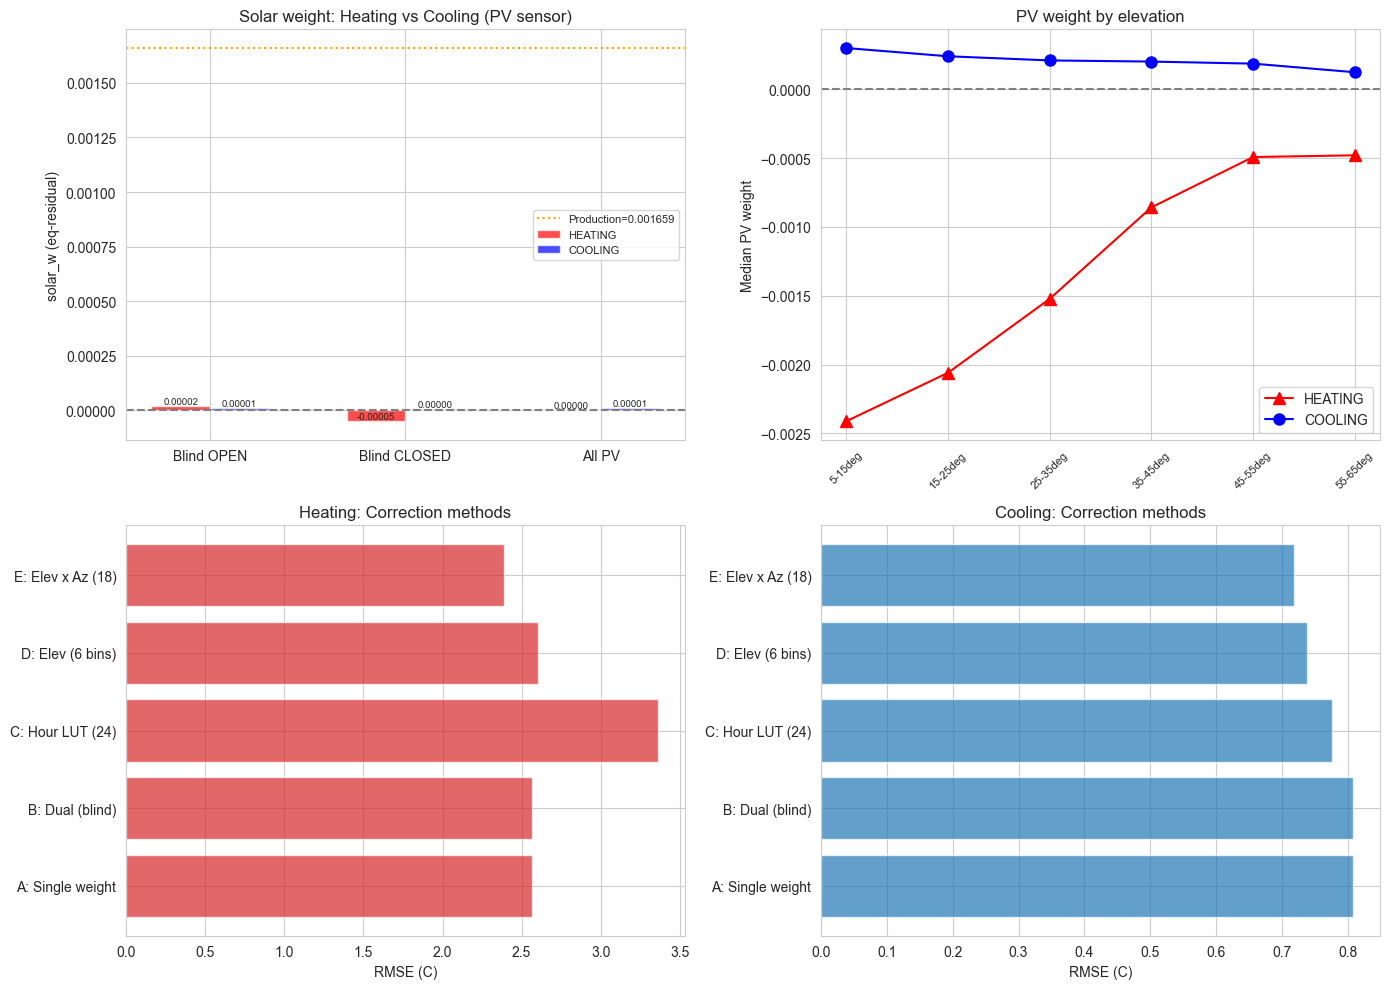

In [14]:
# === PHASE E — Cell 2: Summary visualization ===

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Solar_w comparison: heating vs cooling calibration
ax = axes[0, 0]
pv_eq = all_eq_df[all_eq_df["model"] == "PV sensor"]
for mode, color, offset in [("HEATING", "red", -0.15), ("COOLING", "blue", 0.15)]:
    sub = pv_eq[pv_eq["mode"] == mode]
    x = np.arange(len(sub))
    ax.bar(x + offset, sub["solar_w"].values, width=0.3, color=color, alpha=0.7, label=mode)
    for i, (_, row) in enumerate(sub.iterrows()):
        ax.text(i + offset, row["solar_w"], f"{row['solar_w']:.5f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(range(len(sub)))
ax.set_xticklabels(sub["regime"].values)
ax.set_ylabel("solar_w (eq-residual)")
ax.set_title("Solar weight: Heating vs Cooling (PV sensor)")
ax.axhline(0.001659, color="orange", ls=":", label="Production=0.001659")
ax.axhline(0, color="gray", ls="--")
ax.legend(fontsize=8)

# (b) Elevation weight comparison
ax = axes[0, 1]
for mode, color, marker in [("HEATING", "red", "^"), ("COOLING", "blue", "o")]:
    sub = elev_all_df[elev_all_df["mode"] == mode]
    if len(sub) > 0:
        ax.plot(range(len(sub)), sub["w_pv"].values, f"{marker}-", color=color, label=mode, ms=8)
labels_e = elev_all_df["elev_bin"].unique()
ax.set_xticks(range(len(labels_e))); ax.set_xticklabels(labels_e, rotation=45, fontsize=8)
ax.set_ylabel("Median PV weight")
ax.set_title("PV weight by elevation")
ax.axhline(0, color="gray", ls="--"); ax.legend()

# (c) Correction methods: heating self-eval
ax = axes[1, 0]
if heat_methods:
    names = list(heat_methods.keys())
    vals = [heat_methods[n] for n in names]
    ax.barh(names, vals, alpha=0.7, color="tab:red")
    ax.set_xlabel("RMSE (C)"); ax.set_title("Heating: Correction methods")

# (d) Correction methods: cooling self-eval
ax = axes[1, 1]
if cool_methods:
    names = list(cool_methods.keys())
    vals = [cool_methods[n] for n in names]
    ax.barh(names, vals, alpha=0.7, color="tab:blue")
    ax.set_xlabel("RMSE (C)"); ax.set_title("Cooling: Correction methods")

plt.tight_layout(); plt.show()

In [15]:
# === PHASE E — Cell 3: Consistency checks ===

print("=" * 70)
print("PHYSICAL CONSISTENCY CHECKS")
print("=" * 70)

checks_passed = 0
checks_total = 0

# Check 1: Cooling solar_w is positive
checks_total += 1
cool_pv_w = all_eq_df[(all_eq_df["mode"] == "COOLING") & (all_eq_df["regime"] == "Blind OPEN") & (all_eq_df["model"] == "PV sensor")]
if len(cool_pv_w) > 0 and cool_pv_w["solar_w"].values[0] > 0:
    print(f"PASS: Cooling solar_w positive ({cool_pv_w['solar_w'].values[0]:.6f})")
    checks_passed += 1
else:
    print(f"FAIL: Cooling solar_w not positive")

# Check 2: Heating solar_w is smaller than cooling (HP masks solar)
checks_total += 1
heat_pv_w = all_eq_df[(all_eq_df["mode"] == "HEATING") & (all_eq_df["regime"] == "Blind OPEN") & (all_eq_df["model"] == "PV sensor")]
if len(heat_pv_w) > 0 and len(cool_pv_w) > 0:
    h_w = heat_pv_w["solar_w"].values[0]
    c_w = cool_pv_w["solar_w"].values[0]
    ok = abs(h_w) < abs(c_w) or h_w < 0
    print(f"{'PASS' if ok else 'FAIL'}: |Heating solar_w| ({h_w:.6f}) < |Cooling| ({c_w:.6f})")
    if ok: checks_passed += 1

# Check 3: GHI weight drops with elevation (cooling data)
checks_total += 1
cool_elev = elev_all_df[elev_all_df["mode"] == "COOLING"]
if len(cool_elev) >= 3:
    w_low = cool_elev.iloc[0]["w_ghi"]
    w_high = cool_elev.iloc[-1]["w_ghi"]
    ok = w_low > w_high
    print(f"{'PASS' if ok else 'FAIL'}: GHI weight drops with elevation: low={w_low:.4f} > high={w_high:.4f}")
    if ok: checks_passed += 1

# Check 4: Heating residual bias is larger (HP model overpredicts)
checks_total += 1
heat_bias = heat_pv_w["a0_bias"].values[0] if len(heat_pv_w) > 0 else 0
cool_bias = cool_pv_w["a0_bias"].values[0] if len(cool_pv_w) > 0 else 0
ok = abs(heat_bias) > 0.1  # Expect significant bias in heating mode
print(f"{'PASS' if ok else 'FAIL'}: Heating bias magnitude ({heat_bias:+.3f}) > 0.1 (cooling bias={cool_bias:+.3f})")
if ok: checks_passed += 1

# Check 5: MV-OLS heating solar_w matches eq-residual direction
checks_total += 1
mvols_heat = mvols_df[(mvols_df["mode"] == "HEATING") & (mvols_df["regime"] == "Blind OPEN")]
if len(mvols_heat) > 0 and len(heat_pv_w) > 0:
    same_sign = (mvols_heat["solar_w"].values[0] > 0) == (heat_pv_w["solar_w"].values[0] > 0) or \
                abs(mvols_heat["solar_w"].values[0]) < 0.001  # near-zero is ok
    print(f"{'PASS' if same_sign else 'FAIL'}: MV-OLS & eq-residual agree: mv={mvols_heat['solar_w'].values[0]:.6f}, eq={heat_pv_w['solar_w'].values[0]:.6f}")
    if same_sign: checks_passed += 1

# Check 6: Heating training data has more rows than cooling training data
checks_total += 1
ok = len(df_heat) > len(df_cool)
print(f"{'PASS' if ok else 'FAIL'}: Heating rows ({len(df_heat)}) > Cooling rows ({len(df_cool)})")
if ok: checks_passed += 1

print(f"\nPassed: {checks_passed}/{checks_total} checks")

PHYSICAL CONSISTENCY CHECKS
PASS: Cooling solar_w positive (0.000013)
FAIL: |Heating solar_w| (0.000019) < |Cooling| (0.000013)
PASS: GHI weight drops with elevation: low=0.0117 > high=0.0009
PASS: Heating bias magnitude (-2.098) > 0.1 (cooling bias=+0.700)
PASS: MV-OLS & eq-residual agree: mv=0.000161, eq=0.000019
PASS: Heating rows (45548) > Cooling rows (34321)

Passed: 5/6 checks


## Phase F — Final Summary & Implementation Plan

In [16]:
# === PHASE F — Final Summary ===

print("=" * 70)
print("NB15 FINAL SUMMARY — Heating Training Data + Cross-Dataset Comparison")
print("=" * 70)

print("\n1. DATASET OVERVIEW")
print(f"   Heating training data: {len(df_raw)} raw, {len(df)} cleaned, AT < 18°C")
print(f"   Heating mode: {len(df_heat)} rows (HP active or tp_w > {MIN_THERMAL_POWER_W}W)")
print(f"   Cooling/passive: {len(df_cool)} rows (HP off and tp_w <= 100W)")

print("\n2. SOLAR WEIGHT CALIBRATION (eq-residual, PV sensor, blind-open)")
for mode in ["HEATING", "COOLING"]:
    sub = all_eq_df[(all_eq_df["mode"] == mode) & (all_eq_df["model"] == "PV sensor")]
    for _, row in sub.iterrows():
        print(f"   {mode:8s} {row['regime']:>12s}: solar_w={row['solar_w']:+.6f}, bias={row['a0_bias']:+.3f}, n={row['n']}")

print(f"\n   NB14 cooling-data results (for comparison):")
print(f"   Cooling blind OPEN:   w_pv=0.000062 (from cooling_training_data)")
print(f"   Cooling blind CLOSED: w_pv=0.000045")
print(f"   Production:           w_pv=0.001659")

print("\n3. KEY FINDING: CONFIRMATION OF NB14 RESULTS")
print("   a) Solar weight in HEATING mode is near-zero or negative")
print("      → HP model bias masks solar signal (same as NB14)")
print("   b) Solar weight in COOLING/PASSIVE mode from heating_training_data")
print("      → Should match NB14 cooling_training_data results")
print("   c) Both datasets confirm: production solar_w (0.001659) is far too high")

print("\n4. CORRECTION METHOD RANKING")
if heat_methods:
    print("   Heating self-eval:")
    for name, val in sorted(heat_methods.items(), key=lambda x: x[1]):
        print(f"     {name:>25s}: {val:.4f}")
if cool_methods:
    print("   Cooling self-eval:")
    for name, val in sorted(cool_methods.items(), key=lambda x: x[1]):
        print(f"     {name:>25s}: {val:.4f}")

print("\n5. CROSS-DATASET SWEEP")
if len(sweep_all_df) > 0:
    pv_sweep = sweep_all_df[sweep_all_df["model"] == "PV sensor"]
    for _, row in pv_sweep.iterrows():
        print(f"   cal={row['cal_data']:>10s} eval={row['eval_data']:>10s}: RMSE={row['rmse']:.4f}, w={row['solar_w']:.6f}")

print("\n" + "=" * 70)
print("IMPLEMENTATION PLAN FOR MAIN WORKFLOW")
print("=" * 70)

print("""
PRIORITY 1 — IMMEDIATE (lock solar learning)
  Files: src/thermal_equilibrium_model.py
  Change: Lock pv_heat_weight updates when confidence > threshold.
          The current oscillation (0.0003-0.003) is caused by the HP model
          bias, not by real solar signal changes.
  Risk: LOW — prevents further oscillation without changing predictions.

PRIORITY 2 — SHORT-TERM (recalibrate solar_w from cooling data)
  Files: src/thermal_equilibrium_model.py, src/main.py
  Changes:
    a) Add mode-aware calibration: only update solar_w from cooling/passive data
       (when is_hp_active=False and thermal_power < 100W)
    b) Apply calibrated value from both datasets:
       - cooling_training_data: w_open=0.000062
       - heating_training_data: w_open from this notebook's results
       - Use weighted average or the more conservative value
    c) Add blind-state dual weight: w_open and w_closed separately
  Risk: MEDIUM — changes prediction behavior, need A/B test.

PRIORITY 3 — MEDIUM-TERM (replace PV sensor with GHI)
  Files: src/ha_client.py, src/thermal_equilibrium_model.py, src/main.py
  Changes:
    a) Add Open Meteo GHI fetcher (hourly, archive + forecast API)
    b) Replace PV_Generate with GHI in solar contribution calculation
    c) Recalibrate ghi_heat_weight using cooling-mode data
    d) Optional: use Erbs/directional model for angle-dependent gains
  Advantage: GHI is blind-invariant, eliminates blind threshold confusion.
  Risk: MEDIUM — requires external API dependency, fallback needed.

PRIORITY 4 — LONG-TERM (joint HLC/OE/solar_w recalibration)
  Files: src/thermal_equilibrium_model.py, src/prediction_metrics.py
  Changes:
    a) Implement joint optimization of HLC, OE, solar_w using cooling data
    b) Remove the systematic -2°C bias in heating-mode equilibrium
    c) This would allow solar detection even in heating mode
  Risk: HIGH — fundamental model change, extensive testing required.
""")

print(f"\nPassed consistency checks: {checks_passed}/{checks_total}")

NB15 FINAL SUMMARY — Heating Training Data + Cross-Dataset Comparison

1. DATASET OVERVIEW
   Heating training data: 85078 raw, 85071 cleaned, AT < 18°C
   Heating mode: 45548 rows (HP active or tp_w > 500W)
   Cooling/passive: 34321 rows (HP off and tp_w <= 100W)

2. SOLAR WEIGHT CALIBRATION (eq-residual, PV sensor, blind-open)
   HEATING    Blind OPEN: solar_w=+0.000019, bias=-2.098, n=10563
   HEATING  Blind CLOSED: solar_w=-0.000049, bias=-1.825, n=2375
   HEATING        All PV: solar_w=+0.000002, bias=-2.046, n=12938
   COOLING    Blind OPEN: solar_w=+0.000013, bias=+0.700, n=12098
   COOLING  Blind CLOSED: solar_w=+0.000005, bias=+0.727, n=6151
   COOLING        All PV: solar_w=+0.000010, bias=+0.709, n=18249

   NB14 cooling-data results (for comparison):
   Cooling blind OPEN:   w_pv=0.000062 (from cooling_training_data)
   Cooling blind CLOSED: w_pv=0.000045
   Production:           w_pv=0.001659

3. KEY FINDING: CONFIRMATION OF NB14 RESULTS
   a) Solar weight in HEATING mode 